In [126]:
import sys
sys.path.append('..')  # pour importer portfolio_analytics depuis la racine
%load_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
import numpy as np
import portfolio_analytics as erk

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import pandas as pd
import numpy as np
def gbm(n_years = 10, n_scenarios = 1000, mu = 0.07, sigma=0.15, steps_per_year=12, s_0=100.0):
    """Evolution of a Stock Price using a Geometric Brownian Motion Model"""
    dt = 1/steps_per_year
    n_steps = int(n_years*steps_per_year)
    xi = np.random.normal(size=(n_steps, n_scenarios))
    rets = mu*dt + sigma*np.sqrt(dt)*xi
    rets = pd.DataFrame(rets)
    # to prices
    prices = s_0*(1+rets).cumprod()
    return prices

In [128]:
p = gbm(10, n_scenarios=3)

In [129]:
p.shape

(120, 3)

In [130]:
p.tail()

,0,1,2
115,168.957090,93.558940,171.224196
116,168.934128,93.418892,168.777000
117,161.208486,86.339369,154.323921
118,148.996521,89.467336,157.979828
119,155.547626,84.654587,153.575946


<Axes: >

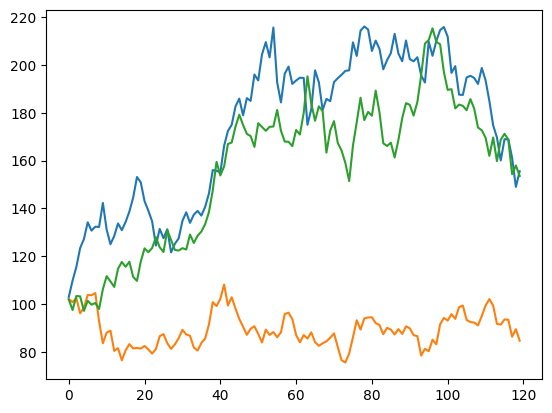

In [131]:
p.plot(legend=None)

In [132]:
p = gbm(n_years=10,n_scenarios=1000)

In [133]:
def gbm0(n_years = 10, n_scenarios = 1000, mu = 0.07, sigma=0.15, steps_per_year=12, s_0=100.0):
    """Evolution of a Stock Price using a Geometric Brownian Motion Model"""
    dt = 1/steps_per_year
    n_steps = int(n_years*steps_per_year)
    xi = np.random.normal(size=(n_steps, n_scenarios))
    rets = mu*dt + sigma*np.sqrt(dt)*xi
    rets = pd.DataFrame(rets)
    # to prices?
    prices = s_0*(1+rets).cumprod()
    return prices
def gbm(n_years = 10, n_scenarios = 1000, mu = 0.07, sigma=0.15, steps_per_year=12, s_0=100.0):
    """Evolution of a Stock Price using a Geometric Brownian Motion Model"""
    dt = 1/steps_per_year
    n_steps = int(n_years*steps_per_year)
    rets_plus_1 = np.random.normal(loc=(1+mu*dt),scale=(sigma*np.sqrt(dt)),size=(n_steps, n_scenarios))
    # to prices
    prices = s_0*pd.DataFrame(rets_plus_1).cumprod()
    return prices

In [134]:
%timeit gbm0(n_years=5, n_scenarios=1000)

4.58 ms ± 1.1 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [135]:
%timeit gbm1(n_years=5, n_scenarios=1000)

4.34 ms ± 910 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


<Axes: >

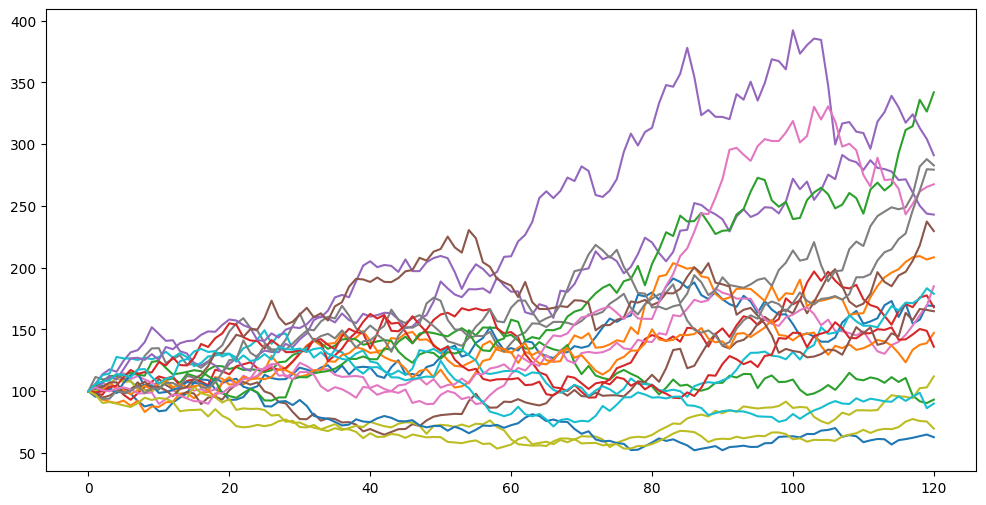

In [138]:
gbm(n_years=10,n_scenarios=20).plot(legend=False, figsize=(12,6))

In [137]:
def gbm(n_years = 10, n_scenarios = 1000, mu = 0.07, sigma=0.15, steps_per_year=12, s_0=100.0):
    """Evolution of a Stock Price using a Geometric Brownian Motion Model"""
    dt = 1/steps_per_year
    n_steps = int(n_years*steps_per_year)
    rets_plus_1 = np.random.normal(loc=(1+mu*dt),scale=(sigma*np.sqrt(dt)),size=(n_steps+1, n_scenarios))
    rets_plus_1[0]=1
    # to prices
    prices = s_0*pd.DataFrame(rets_plus_1).cumprod()
    return prices

In [140]:
gbm(n_scenarios=10).head()

,0,1,2,3,4,5,6,7,8,9
0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1,94.971065,89.647749,98.301097,104.870446,98.198534,98.540097,95.549357,103.921465,99.960695,106.792114
2,104.827208,86.553671,96.966102,112.623289,103.208829,101.312343,86.893356,103.612113,107.284408,109.677141
3,101.568031,85.715738,90.392026,113.665319,103.680232,106.024076,90.518659,95.333316,106.510605,114.503533
4,105.612157,89.421628,96.068457,113.219999,103.176712,116.555796,96.645150,94.605626,106.783900,113.374674
